In [1]:
import corner
import datetime as dt 
import logging
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import ocnus_py
from ocnus_py import NC16, Univariate, MFRFilter, BasicConf3Series

logging.basicConfig(format='%(levelname)s %(filename)s:%(lineno)d %(asctime)-15s %(message)s')
logging.getLogger().setLevel(logging.INFO)

In [2]:
# Set up model priors
model = NC16([
    Univariate.uniform("phi", 0.5 * np.pi, 2.5 * np.pi),
    Univariate.uniform("theta", - np.pi / 2, np.pi / 2),
    Univariate.uniform("y_0", -0.95, 0.95),
    Univariate.uniform("radius", 0.025, 0.2),
    Univariate.uniform("x_0", 0.5, 1.0),
    Univariate.constant("speed", 500),
    Univariate.uniform("b_star", 10, 25),
    Univariate.uniform("tau", 1, 2),
    Univariate.uniform("c10", -15.0, 15.0),
])

ref_data = np.array([
    [np.nan, np.nan, np.nan],
    [-3.13531505, -13.98423491, -6.64658269],
    [-3.38360946, -15.34720671, -1.71139834],
    [-4.21540068, -13.93568105, 4.73878965],
    [-5.41469694, -13.9772912, 4.14112123],
    [-4.30711573, -12.61217154, 5.78382821],
    [np.nan, np.nan, np.nan],
])

ref_timestamps = np.array([4.0 * 3600.0 * i for i in range(len(ref_data))])

ref_trajectory = np.array([
    [1.0, 0.0, 0.0] * len(ref_data)
]).reshape((-1, 3)).T

In [3]:
fitter = MFRFilter(
    model, [ref_timestamps], [ref_trajectory], [ref_data],
    metric="nrmse", size=2048,
    initial_seed=45, max_attempts=1000, simulation_time_limit=10.0,
)

particles_init = fitter.filter.particles()

mutations = fitter.dev(steps=200, metric="nchisq", mutation_factor=0.1, recombination_factor=0.9, abort=1)

particles = fitter.filter.particles()

AttributeError: 'builtins.NC16MFRFilter' object has no attribute 'dev'

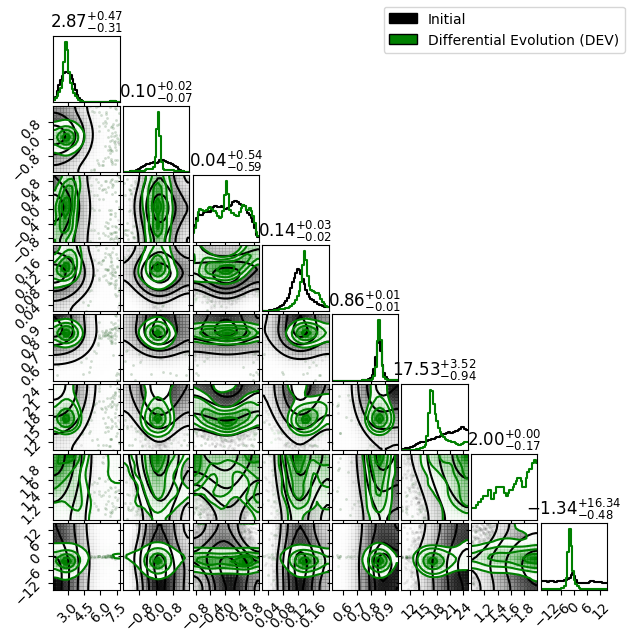

In [ ]:
autorange = np.array([np.min(particles_init[0], axis=0), np.max(particles_init[0], axis=0)]).T
autoflag = [True for _ in autorange]

for idx in range(len(autorange)):
        if autorange[idx][0] == autorange[idx][1]:
                autoflag[idx] = False

cfig = plt.figure(figsize=(6, 6))
corner.corner(particles_init[0].T[autoflag].T, 
              weights=None, color='k',
              range=autorange[autoflag], fig=cfig, smooth=5.0, 
              smooth1d=1.0, bins=20, hist_bin_factor=2)
corner.corner(particles[0].T[autoflag].T, 
              weights=None, color='g',
              range=autorange[autoflag], fig=cfig, smooth=2.0, 
              smooth1d=1.0, bins=20, hist_bin_factor=2, show_titles=True)
cfig.legend(handles=[
    Patch(facecolor='k', edgecolor='k', label="Initial"),
    Patch(facecolor='g', edgecolor='k', label="Differential Evolution (DEV)"),
], loc='upper right')
plt.show()